[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/05_industry_applications/19_segmentation_recommenders.ipynb)

# 📓 Notebook 19 — Customer Segmentation & Recommenders

Everything so far predicted a *label*. This notebook answers two label-free questions every commercial team asks: **"which kinds of customers do we have?"** (segmentation) and **"what should we show each of them next?"** (recommendation). It's also the course's introduction to **unsupervised learning** — finding structure when nobody tells you the right answer.

> 🧠 **Mental model.** Segmentation compresses thousands of customers into 4–6 *personas a human can reason about*. A recommender does the opposite: it makes a decision *per customer per product*, too granular for any human. The two bracket the same business need at different resolutions.

## 🎯 Learning objectives

By the end you can:

1. Build an **RFM segmentation** (recency, frequency, monetary) — the 40-year-old workhorse that still runs most retention email programs.
2. Use **k-means** properly: scale first, choose k with the elbow *and* silhouette, then **profile and name** the clusters.
3. Explain why clustering without scaling silently becomes "sort by revenue".
4. Build an **item-item collaborative-filtering** recommender with cosine similarity (the same cosine as NB 23!) and beat the popularity baseline.
5. Evaluate a recommender offline with **hit-rate@k / leave-one-out** — and say honestly what offline metrics can't tell you.

## ✅ Prerequisites

Notebooks 1–16 (especially NB 7 — groupby/pivot, NB 16 — scaling). NB 23's cosine similarity returns for an encore. Data generated inline; runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
pd.set_option("display.width", 120)
print("Setup OK")


Setup OK


## 1. The data: a B2B webshop's order history

HelpDeskAI's parent company also runs a webshop for office & IT supplies (12 products, 1,200 business customers, 18 months of orders). Four behavioural archetypes are planted in the generator — your job is to *recover* them without ever being told they exist.

In [2]:
PRODUCTS = ["laptop", "monitor", "dock", "headset", "webcam", "desk", "chair",
            "paper", "toner", "coffee", "snacks", "whiteboard"]
archetype = rng.choice(["tech_buyer", "office_manager", "pantry", "one_off"],
                       size=1200, p=[0.25, 0.30, 0.25, 0.20])
pref = {                                   # product preference weights per archetype
 "tech_buyer":     [8, 6, 5, 4, 3, 0.5, 0.5, 0.3, 0.3, 0.5, 0.3, 0.5],
 "office_manager": [1, 1, 1, 1, 1, 4, 4, 6, 5, 1, 1, 3],
 "pantry":         [0.1, 0.1, 0.2, 0.2, 0.1, 0.3, 0.3, 2, 1, 9, 8, 0.5],
 "one_off":        [2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1],
}
n_orders  = {"tech_buyer": (8, 25), "office_manager": (12, 35), "pantry": (20, 60), "one_off": (1, 3)}
price     = dict(zip(PRODUCTS, [900, 250, 120, 60, 45, 400, 220, 8, 70, 15, 12, 95]))

rows = []
for cust_id, arch in enumerate(archetype):
    k = rng.integers(*n_orders[arch])
    p = np.array(pref[arch], float); p /= p.sum()
    recency_bias = 540                                 # order days spread over the full 18 months
    for _ in range(k):
        prod = PRODUCTS[rng.choice(len(PRODUCTS), p=p)]
        rows.append({"customer_id": cust_id, "product": prod,
                     "qty": int(rng.integers(1, 6)),
                     "day": int(rng.integers(0, recency_bias))})
orders = pd.DataFrame(rows)
orders["revenue"] = orders["qty"] * orders["product"].map(price)
TODAY = 540
print(orders.head())
print(f"\n{len(orders):,} order lines, {orders['customer_id'].nunique():,} customers, "
      f"{orders['revenue'].sum()/1e6:.2f}M EUR total")


   customer_id product  qty  day  revenue
0            0  coffee    3  207       45
1            0  snacks    5  250       60
2            0   chair    1  502      220
3            0  coffee    4  334       60
4            0  coffee    2  139       30

25,297 order lines, 1,200 customers, 10.45M EUR total


## 2. RFM — segmentation you can build before lunch

Score every customer on **R**ecency (days since last order), **F**requency (number of orders), **M**onetary (total revenue) — then cut each into quintiles 1–5. No model, no tuning, instantly explainable. This is what most "customer 360" dashboards actually run.

In [3]:
rfm = orders.groupby("customer_id").agg(
        recency=("day", lambda d: TODAY - d.max()),
        frequency=("day", "count"),
        monetary=("revenue", "sum"))
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)   # recent = good = 5
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

def rfm_label(row):
    if row.R >= 4 and row.F >= 4:  return "Champions"
    if row.R >= 4 and row.F <= 2:  return "New / promising"
    if row.R <= 2 and row.F >= 4:  return "At risk (was loyal)"
    if row.R <= 2 and row.F <= 2:  return "Hibernating"
    return "Regulars"
rfm["segment"] = rfm.apply(rfm_label, axis=1)
print(rfm["segment"].value_counts().to_string())
print()
print(rfm.groupby("segment")[["recency", "frequency", "monetary"]].mean().round(0))


segment
Regulars               410
Hibernating            335
Champions              302
New / promising         90
At risk (was loyal)     63

                     recency  frequency  monetary
segment                                          
At risk (was loyal)     48.0       32.0    9648.0
Champions                7.0       37.0    7976.0
Hibernating            199.0        5.0    4391.0
New / promising          7.0       12.0   10471.0
Regulars                25.0       23.0   12232.0


**The RFM segments at a glance.** The value table is clearer as a picture: how many customers fall in each segment, and how much each segment is worth on average. "Champions" are few but precious; "Hibernating" are many but cheap — that split is the whole point of segmenting.


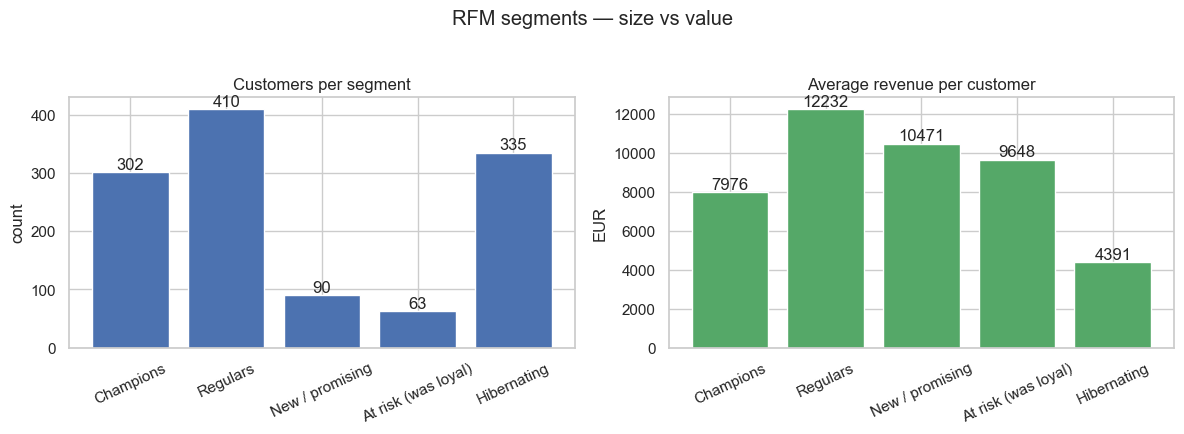

In [4]:
seg = rfm.groupby("segment").agg(customers=("monetary", "size"),
                                avg_revenue=("monetary", "mean"))
order = [s for s in ["Champions", "Regulars", "New / promising",
                     "At risk (was loyal)", "Hibernating"] if s in seg.index]
seg = seg.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
b0 = axes[0].bar(seg.index, seg["customers"], color="#4C72B0")
axes[0].bar_label(b0); axes[0].set(title="Customers per segment", ylabel="count")
b1 = axes[1].bar(seg.index, seg["avg_revenue"], color="#55A868")
axes[1].bar_label(b1, fmt="%.0f"); axes[1].set(title="Average revenue per customer", ylabel="EUR")
for ax in axes: ax.tick_params(axis="x", rotation=25)
fig.suptitle("RFM segments — size vs value", y=1.03)
plt.tight_layout(); plt.show()


💡 **Why RFM survives every ML wave:** each axis is an action lever. *At risk + high M* → NB 17's retention offer. *New / promising* → onboarding nudge. *Champions* → referral program. The segmentation is the campaign plan.

## 3. K-means — letting the data draw the lines

RFM cuts on three hand-picked axes. K-means instead finds groups in *any* feature space — here: spend share per product category plus order cadence. Two iron rules: **scale first** (NB 16) and **profile after**.

### 🔬 What actually happens inside k-means — the assign/update loop

In the next cells, `KMeans(...).fit(X_scaled)` will be one line — but it hides a tiny loop that repeats just **two steps** until the clusters stop moving. Watching that loop run by hand is what makes k-means stop being magic.

k-means needs you to pick **k** (how many clusters) up front. It then drops k *centroids* (cluster centres) somewhere, and repeats:

```text
   ┌─────────────────────────────────────────────────────────┐
   │  repeat until nothing changes:                          │
   │                                                         │
   │   STEP 1 — ASSIGN                                       │
   │     give each POINT to its NEAREST centroid             │
   │     (this carves the space into k groups)               │
   │                                                         │
   │   STEP 2 — UPDATE                                       │
   │     move each CENTROID to the AVERAGE (mean) position   │
   │     of the points that were just assigned to it         │
   └─────────────────────────────────────────────────────────┘
```

That's the whole algorithm. **Assign points to nearest centre, then move each centre to its points' average — over and over.** Each pass nudges the centroids toward the dense part of their group; after a few passes nobody switches groups and the centroids stop moving. Done.

> 🧠 **Mental model.** k-means = repeat {assign each point to the nearest centre; move each centre to its points' average} until nothing changes. It's *hill-climbing on total within-cluster distance* — every step can only make that distance smaller or leave it equal, which is why it always settles.


### A tiny 2-D example to watch it move

Forget the 1,200-customer matrix for a moment. Here are **9 points** in 2-D, clearly forming three blobs (bottom-left, top-left, right). We'll ask k-means for **k = 3** and run the assign→update loop *by hand* with numpy — no sklearn yet — printing the centroids after each pass.

```text
 y
 8 |              ● ●          ← top-left blob
 7 |              ●
 6 |
 5 |                      ● ●  ← right blob
 4 |                      ●
 3 |
 2 |   ● ●
 1 |   ●                       ← bottom-left blob
 0 +-------------------------- x
     0  1  2   ...   7  8  9
```

We deliberately start the 3 centroids at **bad** spots (all near the bottom-left) so you can see them *walk* to the blobs over a couple of iterations.


In [5]:
import numpy as np

# 9 points in 2-D forming three obvious blobs (bottom-left, top-left, right)
P = np.array([
    [1, 1], [1, 2], [2, 2],          # bottom-left blob
    [1, 7], [1, 8], [2, 8],          # top-left blob
    [8, 4], [8, 5], [9, 5],          # right blob
], dtype=float)

# Start the 3 centroids at BAD positions (all bunched in the bottom-left) on
# purpose, so we can watch them walk out to the three blobs.
C = np.array([[1.0, 0.0], [2.0, 3.0], [3.0, 1.0]])   # k = 3 starting centroids

print("starting centroids (deliberately bad — all bottom-left):\n", C)
print(f"\n{len(P)} points, k=3 clusters")

starting centroids (deliberately bad — all bottom-left):
 [[1. 0.]
 [2. 3.]
 [3. 1.]]

9 points, k=3 clusters


### One pass = one ASSIGN + one UPDATE

The cell below does **one full iteration** as a function, so we can call it repeatedly and print the centroids creeping toward the blobs. Both steps are tiny:

- **ASSIGN:** for every point, compute its distance to each centroid, then `argmin` picks the nearest. (We use *squared* distance — the comparison gives the same winner and avoids a square root.)
- **UPDATE:** for each cluster, the new centroid is the column-wise `mean` of the points currently assigned to it.


In [6]:
def assign(points, centroids):
    """STEP 1 — label each point with the index of its NEAREST centroid."""
    # distances[i, j] = squared distance from point i to centroid j
    diff = points[:, None, :] - centroids[None, :, :]      # (n_points, k, 2)
    sq_dist = (diff ** 2).sum(axis=2)                       # (n_points, k)
    return sq_dist.argmin(axis=1)                           # nearest centroid per point

def update(points, labels, k):
    """STEP 2 — move each centroid to the MEAN of the points assigned to it."""
    return np.array([points[labels == j].mean(axis=0) for j in range(k)])

def inertia_demo(points, labels, centroids):
    """Total within-cluster squared distance — the quantity k-means shrinks."""
    return sum(((points[labels == j] - centroids[j]) ** 2).sum()
               for j in range(len(centroids)))

# --- run the loop by hand, printing what happens each pass ---
C = np.array([[1.0, 0.0], [2.0, 3.0], [3.0, 1.0]])   # reset to the bad start
prev_labels = None
for step in range(1, 8):
    labels = assign(P, C)                 # STEP 1: assign
    C = update(P, labels, k=3)            # STEP 2: update (move centres)
    print(f"pass {step}: assignments = {labels.tolist()}  "
          f"within-cluster dist = {inertia_demo(P, labels, C):6.2f}")
    if np.array_equal(labels, prev_labels):
        print("   ↳ assignments stopped changing — CONVERGED ✅")
        break
    prev_labels = labels

print("\nfinal centroids (one per blob):\n", C.round(2))

pass 1: assignments = [0, 1, 1, 1, 1, 1, 2, 1, 2]  within-cluster dist =  77.83
pass 2: assignments = [0, 0, 0, 1, 1, 1, 2, 2, 2]  within-cluster dist =   4.00
pass 3: assignments = [0, 0, 0, 1, 1, 1, 2, 2, 2]  within-cluster dist =   4.00
   ↳ assignments stopped changing — CONVERGED ✅

final centroids (one per blob):
 [[1.33 1.67]
 [1.33 7.67]
 [8.33 4.67]]


Read the printout top to bottom: the **within-cluster distance never goes up** — it shrinks every pass until it can't, exactly as promised. The **assignments freeze** after a couple of passes (nobody's nearest centroid changes anymore), and the three final centroids land neatly in the middle of the three blobs. That freeze *is* convergence: assign and update can no longer disagree, so the loop stops.

### Cross-check: sklearn's `KMeans` finds the same centroids

Our hand-rolled loop is the real algorithm, just spelled out. If we hand the *same* 9 points to scikit-learn, it lands on the *same* three centres (allowing for the arbitrary order/labelling of clusters):


In [7]:
try:
    from sklearn.cluster import KMeans
    km_check = KMeans(n_clusters=3, n_init=10, random_state=0).fit(P)
    order   = lambda M: M[np.lexsort((M[:, 1], M[:, 0]))].round(2)  # sort rows by (x, y)
    ours    = order(C)                                  # row order ignores cluster labelling
    skl     = order(km_check.cluster_centers_)
    print("our centroids      (sorted):\n", ours)
    print("\nsklearn centroids  (sorted):\n", skl)
    print("\nsame centres?", np.allclose(ours, skl, atol=0.01))
except ModuleNotFoundError:
    print("sklearn not installed — the hand-rolled loop above already IS k-means.")

our centroids      (sorted):
 [[1.33 1.67]
 [1.33 7.67]
 [8.33 4.67]]

sklearn centroids  (sorted):
 [[1.33 1.67]
 [1.33 7.67]
 [8.33 4.67]]

same centres? True


### Three things the loop just taught us (and why they matter for segmentation)

1. **You must pick k.** The algorithm never decides how many clusters exist — *you* told it 3. That's exactly why §3 spends effort on the **elbow + silhouette** plots (coming up in the next cell): they're how you choose k when, unlike here, the blobs aren't obvious.
2. **Initialization matters.** We started the centroids at bad spots and they still recovered — but with unlucky starts k-means can settle into a *worse* arrangement (a different valley of the hill it's climbing). That's why real code passes **`n_init=10`**: run the whole loop 10 times from different random starts and keep the best. (Watch for it — every `KMeans(...)` call in this notebook sets `n_init=10`.)
3. **It finds round, roughly equal-sized clusters.** Because "nearest centroid" carves space with straight-line distance, k-means prefers compact, blob-shaped groups. Long stringy or wildly different-sized groups are where it struggles — a limitation worth remembering when a cluster profile looks odd.

> ⚠️ **The scaling connection.** "Nearest centroid" uses raw Euclidean distance, so a feature measured in big units (revenue in euros) drowns out one in small units (order count). That's the *exact* reason §3 insists on `StandardScaler` **before** `KMeans` — and what Exercise 3's "revenue-sorted clusters" bug is all about. The assign step you just watched is precisely where unscaled features do their damage.

> 🎯 **Takeaway.** When you call `KMeans(n_clusters=4).fit(X_scaled)` in the next cell, picture these two steps spinning a few times: assign every customer to the nearest of 4 centres, move each centre to its customers' average, repeat until the personas stop reshuffling.


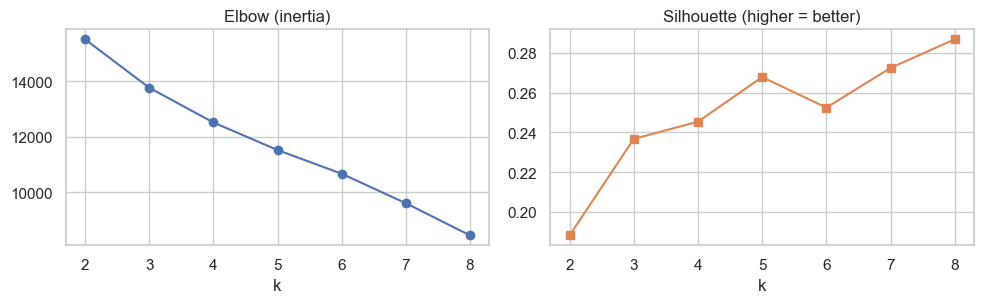

{2: 0.188, 3: 0.237, 4: 0.245, 5: 0.268, 6: 0.252, 7: 0.272, 8: 0.287}


In [8]:
# Behavioural features: what share of a customer's revenue goes to each product?
share = (orders.pivot_table(index="customer_id", columns="product", values="revenue",
                            aggfunc="sum", fill_value=0))
share = share.div(share.sum(axis=1), axis=0)
beh = share.join(rfm[["recency", "frequency", "monetary"]])

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_scaled = StandardScaler().fit_transform(beh)

inertia, sil = {}, {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia[k] = km.inertia_
    sil[k] = silhouette_score(X_scaled, km.labels_)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(list(inertia), list(inertia.values()), "o-"); axes[0].set_title("Elbow (inertia)")
axes[1].plot(list(sil), list(sil.values()), "s-", color="#dd8452"); axes[1].set_title("Silhouette (higher = better)")
for ax in axes: ax.set_xlabel("k")
plt.tight_layout(); plt.show()
print({k: round(v, 3) for k, v in sil.items()})


> 🎯 **Reading the two plots together.** The elbow says "diminishing returns after ~4". The silhouette, meanwhile, keeps creeping upward as k grows — each extra cluster splits off a small, tight group of outliers, which buys a slightly better score (Exercise 2 dissects this effect). The two metrics *disagree*, which is normal: when they do, prefer the k whose *profiles* you can act on — a 9-cluster solution nobody can name is analytically pretty and commercially dead.

## 4. Profile, then *name* — the step everyone skips

In [9]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_scaled)
beh_p = beh.copy(); beh_p["cluster"] = km.labels_

profile = beh_p.groupby("cluster").agg(
    n=("monetary", "size"), revenue=("monetary", "mean"),
    orders=("frequency", "mean"), recency_days=("recency", "mean"),
    top_categories=("cluster", lambda c: ", ".join(
        share.loc[beh_p[beh_p.cluster == c.iloc[0]].index].mean().nlargest(3).index)))
print(profile.round(0).to_string())

# how well did we recover the planted archetypes? (only possible because we OWN the generator)
recovered = pd.crosstab(beh_p["cluster"], pd.Series(archetype, name="true archetype"))
print("\nCluster vs hidden archetype:\n", recovered.to_string())


           n  revenue  orders  recency_days         top_categories
cluster                                                           
0        288   3375.0    38.0          35.0  coffee, snacks, toner
1        456   7468.0    18.0          76.0     desk, chair, toner
2          9     31.0     1.0         358.0   paper, chair, coffee
3        447  13574.0    14.0          78.0  laptop, monitor, dock

Cluster vs hidden archetype:
 true archetype  office_manager  one_off  pantry  tech_buyer
cluster                                                    
0                            0       22     266           0
1                          315      115      25           1
2                            0        9       0           0
3                           27       94      16         310


💡 **In real life there is no `archetype` column to check against** — that crosstab is a luxury of synthetic data. The production substitute is *stability* (re-cluster on a bootstrap sample: do the same groups re-appear?) and *actionability* (can marketing write a different email per cluster without laughing?).

## 5. The recommender — "customers who bought X also bought…"

**Item-item collaborative filtering**, the architecture that ran Amazon's recommendations for a decade: represent each product as the vector of customers who bought it, compute **cosine similarity** between products (NB 23, same formula, new matrix), and recommend the most-similar items a customer hasn't bought yet.

In [10]:
# customer x product purchase matrix (1 = bought at least once)
upm = (orders.pivot_table(index="customer_id", columns="product", values="qty",
                          aggfunc="sum", fill_value=0) > 0).astype(int)

from sklearn.metrics.pairwise import cosine_similarity
item_sim = pd.DataFrame(cosine_similarity(upm.T), index=upm.columns, columns=upm.columns)
# fill_diagonal needs a writeable array; DataFrame.values can be read-only under
# pandas copy-on-write (newer pandas / Colab), so build the array explicitly.
_sim = item_sim.to_numpy(copy=True)
np.fill_diagonal(_sim, 0)                             # a product is not its own recommendation
item_sim = pd.DataFrame(_sim, index=upm.columns, columns=upm.columns)

print("Most similar to 'laptop':\n", item_sim["laptop"].nlargest(3).round(2).to_string())
print("\nMost similar to 'coffee':\n", item_sim["coffee"].nlargest(3).round(2).to_string())

def recommend(customer_id, n=3):
    owned = upm.columns[upm.loc[customer_id] == 1]
    scores = item_sim[owned].sum(axis=1).drop(labels=owned)   # similarity to what they own
    return scores.nlargest(n)

print("\nRecommendations for customer 0 (owns:", ", ".join(upm.columns[upm.loc[0] == 1][:4]), "...):")
print(recommend(0).round(2).to_string())


Most similar to 'laptop':
 product
dock       0.69
monitor    0.68
headset    0.66

Most similar to 'coffee':
 product
paper     0.77
snacks    0.72
toner     0.71

Recommendations for customer 0 (owns: chair, coffee, paper, snacks ...):
product
toner         3.01
whiteboard    2.62
desk          2.45


## 6. Is it any good? Hit-rate@k against the popularity baseline

Offline protocol (**leave-one-out**): hide each customer's most recent purchase, recommend k items from the rest, count a *hit* if the hidden item is in the list. The baseline to beat: always recommend the k globally most popular products — embarrassingly strong in every real system.

In [11]:
last_buy = orders.sort_values("day").groupby("customer_id").tail(1).set_index("customer_id")["product"]
popularity = orders["product"].value_counts()

def hitrate_at_k(k=3):
    hits_cf = hits_pop = evaluated = 0
    pop_top = list(popularity.index)
    for cust, hidden in last_buy.items():
        owned = set(upm.columns[upm.loc[cust] == 1]) - {hidden}
        if not owned: continue
        evaluated += 1
        scores = item_sim[list(owned)].sum(axis=1).drop(labels=list(owned))
        hits_cf  += hidden in set(scores.nlargest(k).index)
        hits_pop += hidden in [p for p in pop_top if p not in owned][:k]
    return hits_cf / evaluated, hits_pop / evaluated, evaluated

hr_cf, hr_pop, n_eval = hitrate_at_k(3)
print(f"hit-rate@3  collaborative: {hr_cf:.2%}   popularity baseline: {hr_pop:.2%}   (n={n_eval})")


hit-rate@3  collaborative: 85.39%   popularity baseline: 59.18%   (n=1068)

**Does the recommender beat 'just show the bestsellers'?** A recommender only earns its keep if it beats the popularity baseline. Sweeping `k` (how many items we recommend) makes the comparison unmissable.


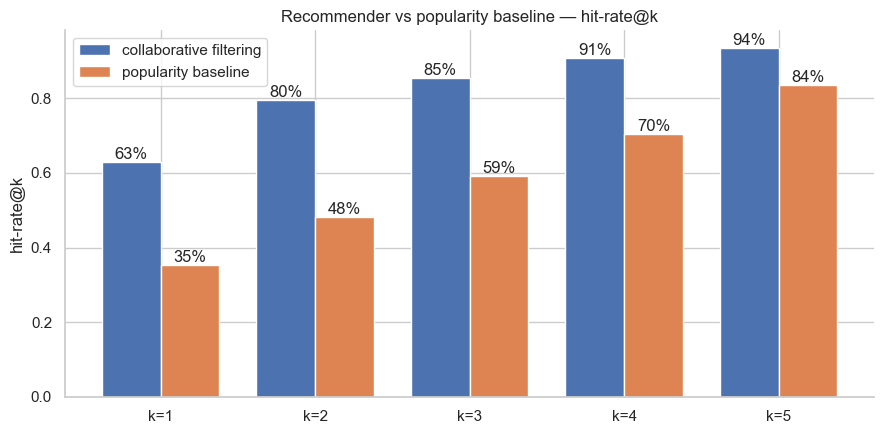

In [12]:
ks = [1, 2, 3, 4, 5]
cf_scores, pop_scores = [], []
for k in ks:
    a, b, _ = hitrate_at_k(k)
    cf_scores.append(a); pop_scores.append(b)

x = np.arange(len(ks)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, cf_scores,  w, color="#4C72B0", label="collaborative filtering")
b2 = ax.bar(x + w/2, pop_scores, w, color="#DD8452", label="popularity baseline")
ax.bar_label(b1, fmt="%.0%%" if False else "{:.0%}".format); ax.bar_label(b2, fmt="{:.0%}".format)
ax.set(xticks=x, xticklabels=[f"k={k}" for k in ks], ylabel="hit-rate@k",
       title="Recommender vs popularity baseline — hit-rate@k")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()


> ⚠️ **What offline hit-rate cannot tell you:** whether the recommendation *caused* anything (the customer might have bought the dock anyway), how it handles **cold-start** (new product = empty column, new customer = empty row → fall back to popularity + attributes), and whether optimizing clicks erodes discovery (filter bubbles). The honest path mirrors NB 17: offline metric → small online A/B → causal read-out.

## 7. When *not* to personalize (the honest section)

- **12 products.** With a catalog this small, a good static cross-sell table gets 90 % of the value. CF starts paying at hundreds of items.
- **B2B contract pricing** often constrains what you may recommend — governance beats relevance (NB 46).
- **Segment-level personas + popularity within segment** is a stronger baseline than most teams admit. Always build it first; make the fancy model beat it.

---

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ Segment value table
For each **RFM segment**, compute: customer count, total 18-month revenue, revenue share (%), and average order value. Which segment would you fund a campaign for first, and which *metric in your own table* argues against the obvious answer?

In [13]:
# Starter
# seg_table = rfm.groupby("segment").agg(...)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
seg_table = rfm.groupby("segment").agg(customers=("monetary", "size"),
                                       revenue=("monetary", "sum"),
                                       orders=("frequency", "sum"))
seg_table["revenue_share_%"] = (100 * seg_table["revenue"] / seg_table["revenue"].sum()).round(1)
seg_table["avg_order_value"] = (seg_table["revenue"] / seg_table["orders"]).round(0)
print(seg_table.sort_values("revenue", ascending=False).to_string())
```

**Why this works:** plain `groupby().agg()` — the analytical muscle from NB 7. The instinctive answer is "fund the Champions", but they're already buying; the *At risk (was loyal)* row usually combines high historical revenue with a recency problem — exactly the population where NB 17's retention math has the most expected value to recover. Read your own table before reaching for the obvious.
</details>

### Exercise 2 — ⭐⭐ Choose k like an adult
Re-run k-means for k = 3, 4, 5 with `n_init=10`, and for each print the silhouette score **and** the size of the smallest cluster. Explain why a great silhouette with a 12-customer cluster is usually the *wrong* choice for marketing.

In [14]:
# Starter
# for k in (3, 4, 5): ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
for k in (3, 4, 5):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    sizes = np.bincount(km_k.labels_)
    print(f"k={k}: silhouette={silhouette_score(X_scaled, km_k.labels_):.3f}, "
          f"cluster sizes={sorted(sizes.tolist())}")
```

**Why this works:** silhouette rewards tight, well-separated clusters — and a tiny outlier group is *very* tight, so it can inflate the score while being commercially useless (you can't build a campaign for 12 accounts… though sales might call them personally). Decision rule: among k values with comparable silhouette, pick the one whose smallest segment is still operationally addressable. Statistics narrows the menu; the business picks the dish.
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: The revenue-sorted "clusters"
A colleague clustered the **raw, unscaled** RFM columns and got four "segments". The cell runs fine and even prints a confident summary. Diagnose what the clusters *actually* are, prove it with one number per cluster, and fix the pipeline.

In [15]:
# A colleague's segmentation — runs without errors. Why are these not behavioural segments?
raw = rfm[["recency", "frequency", "monetary"]]
km_raw = KMeans(n_clusters=4, n_init=10, random_state=42).fit(raw)
rfm_dbg = rfm.copy(); rfm_dbg["raw_cluster"] = km_raw.labels_
print(rfm_dbg.groupby("raw_cluster")[["recency", "frequency", "monetary"]].mean().round(0))
print("\nLooks plausible at first glance... 🚩")


             recency  frequency  monetary
raw_cluster                              
0               28.0       23.0    9536.0
1               27.0       21.0   27146.0
2              114.0       20.0    2577.0
3               27.0       21.0   17546.0

Looks plausible at first glance... 🚩


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# Diagnosis: monetary spans ~100x more units than recency/frequency, so squared euclidean
# distance is dominated by it -> k-means just banded customers by revenue.
ranges = rfm[["recency", "frequency", "monetary"]].agg(["min", "max"]).T
print((ranges["max"] - ranges["min"]).rename("feature range").to_string())

overlap = pd.crosstab(rfm_dbg["raw_cluster"],
                      pd.qcut(rfm_dbg["monetary"], 4, labels=["Q1", "Q2", "Q3", "Q4"]))
print("\nraw clusters vs revenue quartiles (near-diagonal = just sorted by money):\n",
      overlap.to_string())

# Fix: scale, then cluster
fixed = KMeans(n_clusters=4, n_init=10, random_state=42).fit(
            StandardScaler().fit_transform(raw))
print(f"\nsilhouette raw: {silhouette_score(raw, km_raw.labels_):.3f} | "
      f"scaled: {silhouette_score(StandardScaler().fit_transform(raw), fixed.labels_):.3f}")
```

**Why this works:** the crosstab is the smoking gun — each raw "cluster" maps almost one-to-one onto a revenue quartile, so the expensive algorithm reproduced `pd.qcut(monetary, 4)`. Scaling gives every axis equal say (NB 16 §3 said this about KNN and SVMs; k-means belongs on that list, always). The silhouette comparison shows the scaled solution is also *structurally* better, not just more honest.
</details>

### Exercise 4 — ⭐⭐ Explain one recommendation
Recommenders earn trust through explanations. Write `explain_recommendation(customer_id)` that takes the customer's top recommendation and returns a sentence of the form: *"Recommended `dock` because you bought `laptop` (similarity 0.61) and `monitor` (0.48)."* — using the two owned items with the highest similarity to the recommended one.

In [16]:
# Starter
def explain_recommendation(customer_id):
    ...  # your code here

# print(explain_recommendation(0))


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def explain_recommendation(customer_id):
    rec = recommend(customer_id, n=1).index[0]
    owned = upm.columns[upm.loc[customer_id] == 1]
    contrib = item_sim.loc[rec, owned].nlargest(2)
    because = " and ".join(f"`{p}` ({s:.2f})" for p, s in contrib.items())
    return f"Recommended `{rec}` because you bought {because}."

print(explain_recommendation(0))
print(explain_recommendation(5))
```

**Why this works:** item-item CF is *self-explaining* — the score for a candidate is literally a sum of similarities to owned items, so the top contributors ARE the explanation. This transparency is why item-item survived in industry long after fancier methods appeared: "people who bought X buy Y" is an explanation a customer, a marketer, and a regulator all accept (compare NB 46's governance lens).
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Stability: do the segments survive a resample?
Re-fit k-means (k=4) on a 70 % bootstrap sample, assign the held-out 30 % to the nearest new centroid, and build the crosstab against the original cluster labels. What share of customers keep their groupmates, and why is this the production substitute for the archetype crosstab in §4?

In [17]:
# Starter
# boot = beh.sample(frac=0.7, random_state=1) ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
scaler_full = StandardScaler().fit(beh)
Xs = scaler_full.transform(beh)
orig = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xs)

boot_idx = beh.sample(frac=0.7, random_state=1).index
km_boot = KMeans(n_clusters=4, n_init=10, random_state=1).fit(
              scaler_full.transform(beh.loc[boot_idx]))
relabel = km_boot.predict(Xs)

ct = pd.crosstab(orig.labels_, relabel)
agree = ct.max(axis=1).sum() / len(beh)        # best-match agreement (labels permute freely)
print(ct.to_string())
print(f"\nbest-match agreement: {agree:.1%}")
```

**Why this works:** cluster *labels* are arbitrary (cluster 2 may become cluster 0), so stability is measured by the best one-to-one matching — the row-max trick approximates it. High agreement (≫ the 25 % random baseline) means the structure is in the data, not in the seed. In production you run this on every refresh; segments that reshuffle monthly are noise wearing a persona name.
</details>

### Stretch exercise B — ⭐⭐ Segment migration: the early-warning dashboard
Compute RFM twice — once using only days 0–360, once on the full 540 — with the *same* quintile boundaries from the first period. Build the migration matrix between the two segment labels. Which migration flow is the leading indicator NB 17's churn model would love as a feature?

In [18]:
# Starter
# rfm_early = orders[orders.day < 360].groupby(...)


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def rfm_at(day_cut, ref_day):
    o = orders[orders["day"] < day_cut]
    out = o.groupby("customer_id").agg(recency=("day", lambda d: ref_day - d.max()),
                                       frequency=("day", "count"),
                                       monetary=("revenue", "sum"))
    return out

early, late = rfm_at(360, 360), rfm_at(540, 540)
r_bins = pd.qcut(early["recency"], 5, retbins=True, labels=[5,4,3,2,1])[1]
f_bins = pd.qcut(early["frequency"].rank(method="first"), 5, retbins=True, labels=[1,2,3,4,5])[1]

def label(df_):
    R = pd.cut(df_["recency"], r_bins, labels=[5,4,3,2,1], include_lowest=True).astype(float)
    F = df_["frequency"].rank(method="first")
    F = pd.qcut(F, 5, labels=[1,2,3,4,5]).astype(float)
    seg = np.where((R >= 4) & (F >= 4), "Champions",
          np.where((R >= 4) & (F <= 2), "New / promising",
          np.where((R <= 2) & (F >= 4), "At risk (was loyal)",
          np.where((R <= 2) & (F <= 2), "Hibernating", "Regulars"))))
    return pd.Series(seg, index=df_.index)

common = early.index.intersection(late.index)
mig = pd.crosstab(label(early.loc[common]), label(late.loc[common]),
                  rownames=["months 0-12"], colnames=["months 0-18"])
print(mig.to_string())
```

**Why this works:** freezing the *first* period's bin edges makes the two snapshots comparable (recomputing quintiles each period hides drift by construction). The flow to watch is **Champions → At risk**: high-value customers whose recency collapsed. That transition, encoded as a feature ("days since segment downgrade"), is routinely among the strongest churn predictors — the bridge back to NB 17.
</details>

### Stretch exercise C — ⭐⭐ Hybrid: popularity-backed CF
Blend the two §6 systems: `score = α · cf_rank + (1-α) · popularity_rank` (rank-based, like NB 18 Stretch C). Sweep α ∈ {0, 0.25, …, 1} and plot hit-rate@3. Where does the optimum land, and why does pure CF lose for light buyers?

In [19]:
# Starter
# from scipy.stats import rankdata


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy.stats import rankdata

pop_rank = pd.Series(rankdata(popularity.reindex(upm.columns).fillna(0)), index=upm.columns)

def hitrate_hybrid(alpha, k=3):
    hits = evaluated = 0
    for cust, hidden in last_buy.items():
        owned = set(upm.columns[upm.loc[cust] == 1]) - {hidden}
        if not owned: continue
        evaluated += 1
        cf = item_sim[list(owned)].sum(axis=1)
        blend = alpha * pd.Series(rankdata(cf), index=cf.index) + (1 - alpha) * pop_rank
        blend = blend.drop(labels=list(owned))
        hits += hidden in set(blend.nlargest(k).index)
    return hits / evaluated

alphas = [0, 0.25, 0.5, 0.75, 1.0]
hr = [hitrate_hybrid(a) for a in alphas]
print({a: round(h, 3) for a, h in zip(alphas, hr)})
plt.figure(figsize=(6, 3)); plt.plot(alphas, hr, "o-")
plt.xlabel("alpha (CF weight)"); plt.ylabel("hit-rate@3"); plt.tight_layout(); plt.show()
```

**Why this works:** for a customer with one or two purchases, the CF score sums over almost nothing — its ranking is noise, and popularity is the better prior. Rank-blending lets popularity carry light buyers while CF takes over for rich histories; the optimum typically sits strictly inside (0, 1). This is the smallest member of the family that ends, several sizes later, at the hybrid retrieval of NB 23 and the rankers inside every large platform.
</details>

### Stretch exercise D — ⭐⭐⭐ Cold start, both kinds
(a) A new product `"standing_desk"` launches (price €550, similar to `desk`/`chair`): with zero purchases, what does item-item CF score it, and what attribute-based fallback would you implement? (b) A brand-new customer buys only `"toner"` — show the recommendations and explain why they're sane *despite* one data point. Implement both answers.

In [20]:
# Starter — (a) add an all-zeros column; (b) a one-row customer.


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
# (a) new product: all-zero column -> cosine similarity 0 to everything -> never recommended.
upm_a = upm.copy(); upm_a["standing_desk"] = 0
sim_a = pd.DataFrame(cosine_similarity(upm_a.T), index=upm_a.columns, columns=upm_a.columns)
print(f"max similarity of standing_desk to anything: {sim_a['standing_desk'].drop('standing_desk').max():.2f}")
# Fallback: content-based bootstrap — inherit neighbours from ATTRIBUTES until data arrives.
content_neighbours = ["desk", "chair"]                  # same category, similar price band
bootstrap = item_sim[content_neighbours].mean(axis=1)
print("bootstrap 'similar' items via attributes:", ", ".join(bootstrap.nlargest(3).index))

# (b) new customer with a single purchase
new_cust = pd.Series(0, index=upm.columns); new_cust["toner"] = 1
scores = item_sim["toner"].drop(labels=["toner"])
print("\nnew customer who bought toner ->", ", ".join(scores.nlargest(3).index))
```

**Why this works:** (a) is structural — cosine with a zero vector is zero, so new items are invisible to pure CF; every real system bridges the gap with content features (category, price, text embeddings — NB 23 again) until behaviour accumulates. (b) works *because item-item similarities are global*: one purchase selects a column built from 1,200 customers' co-purchases, so even a single data point inherits the crowd's structure (toner buyers are office managers; paper and whiteboards follow). New-*user* cold start is mild in item-item; new-*item* cold start is the hard one.
</details>

## 🎁 Bonus mini-project — the segment one-pager

Write `segment_onepager(cluster_id)` that assembles, for one k-means cluster: its size and revenue share, its three defining categories vs the population average, its RFM character, the top 3 products an item-item recommender would push to it (aggregate the cluster's owned items), and one suggested campaign with an NB 17-style expected-value sketch. Output markdown, one screen, ready for the Monday meeting — and again: numbers from code, prose (if you want it) from NB 22's LLM patterns.

## ✅ Self-assessment checklist

- [ ] I can build RFM from raw orders with `groupby` + `qcut` and defend each segment name.
- [ ] I always scale before k-means and can demonstrate what happens if I don't.
- [ ] I choose k with elbow + silhouette + *smallest-actionable-cluster*, not any one alone.
- [ ] I can implement item-item CF in ~10 lines and explain any recommendation it makes.
- [ ] I can state the two cold-start problems and which one is structurally harder for CF.

## 🚀 Next step

Continue with **Notebook 20 — Demand Forecasting & Predictive Maintenance** (`./20_demand_maintenance.ipynb`): from *who and what* to *how much and when* — the operations side of industry ML, where forecasts become stock orders and sensor streams become repair schedules.